# **Objective of This Notebook**

The purpose of this notebook is to implement, train, and evaluate multiple supervised machine learning regression models for predicting Spotify track popularity using audio and genre-based features. The notebook focuses primarily on the technical modelling workflow, including train-test splitting, baseline benchmarking, model training, performance evaluation, residual analysis, feature importance extraction, and prediction error analysis across popularity ranges.

The emphasis of this notebook is on the implementation and comparison of modelling approaches rather than deep analytical interpretation. Detailed discussion of the results, critical evaluation of model behaviour, practical implications, limitations, and broader analytical insights are intentionally deferred to Notebook 04: *Final Results and Interpretation*.

# **1. Imports and Config**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#import shap #ended up not using this one

import joblib

### **1.1 Paths**

In [2]:
# Automatically detect the project root based on the notebook location
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "featured_df.csv"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
TABLES_PATH = PROJECT_ROOT / "outputs" / "tables"
MODELS_PATH = PROJECT_ROOT / "outputs" / "models"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT, DATA_PATH


(WindowsPath('C:/Users/semoy/OneDrive/Documentos/Keele University/Advanced Application of AI and ML/spotify-popularity-prediction-20260517T121628Z-3-001/spotify-popularity-prediction'),
 WindowsPath('C:/Users/semoy/OneDrive/Documentos/Keele University/Advanced Application of AI and ML/spotify-popularity-prediction-20260517T121628Z-3-001/spotify-popularity-prediction/data/processed/featured_df.csv'))

Checking paths

In [3]:
print(PROJECT_ROOT)
print(DATA_PATH)


C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction
C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\data\processed\featured_df.csv


### **1.2 Load Data**

In [4]:
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset shape: {df.shape}")
    display(df.head(10))
except FileNotFoundError:
    print(f"Error: The file '{DATA_PATH}' was not found.")
    print("Make sure Notebook #1 saved spotify_cleaned.csv correctly.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Dataset shape: (89740, 133)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44,160725,True,0.910,0.374,8,...,0,0,0,0,0,0,0,0,0,0
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47,322933,False,0.269,0.516,0,...,0,0,0,0,0,0,0,0,0,0
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22,515360,False,0.686,0.560,5,...,0,0,0,0,0,0,0,0,0,0
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62,190203,False,0.679,0.770,0,...,0,0,0,0,0,0,0,0,0,0
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19,331240,False,0.519,0.431,6,...,0,0,0,0,0,0,0,0,0,0
5,0017XiMkqbTfF2AUOzlhj6,Chad Daniels,Busy Being Awesome,Thanksgiving Chicken,24,127040,True,0.536,0.780,5,...,0,0,0,0,0,0,0,0,0,0
6,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,...,0,0,0,0,0,0,0,0,0,0
7,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,...,0,0,0,0,0,0,0,0,0,0
8,001pyq8FLNSL1C8orNLI0b,Old Crow Medicine Show,O.C.M.S.,Poor Man,30,214600,False,0.580,0.290,2,...,0,0,0,0,0,0,0,0,0,0
9,002qpSULhHAw6DGqFxbaO1,Tokyo Ghetto Pussy,Disco 2001,Love Generation,17,410666,False,0.531,0.950,9,...,0,0,0,0,0,0,0,0,0,0


# **2. Modelling**

### **2.1 Define Target and Features**

In [5]:
TARGET = "popularity"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (89740, 132)
Target vector shape: (89740,)


In the next cell we remove the columns that are not needed for the modelling

In [6]:
metadata_columns = [
    "track_id",
    "artists",
    "album_name",
    "track_name"
]

X = df.drop(columns=[TARGET] + metadata_columns)
y = df[TARGET]

In [7]:
X.select_dtypes(include="object").columns

Index([], dtype='str')

### **2.2 Train-Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (71792, 128)
Test set: (17948, 128)


The dataset was split into training and testing sets before scaling or model fitting. This avoids data leakage by ensuring that transformations are learned only from the training data.

### **2.3 Evaluation Function**

In [9]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    results = {
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Test MAE": mean_absolute_error(y_test, test_predictions),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_predictions)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_predictions)),
        "Train R2": r2_score(y_train, train_predictions),
        "Test R2": r2_score(y_test, test_predictions)
    }

    return results, test_predictions

### **2.4 Baseline Model**

In [10]:
baseline_model = DummyRegressor(strategy="mean")

baseline_results, baseline_predictions = evaluate_regression_model(
    baseline_model,
    X_train,
    X_test,
    y_train,
    y_test
)

baseline_results

{'Train MAE': 17.22778606855496,
 'Test MAE': 17.252057273621453,
 'Train RMSE': np.float64(20.572630179643674),
 'Test RMSE': np.float64(20.612420893360724),
 'Train R2': 0.0,
 'Test R2': -0.00016677779870044596}

### **2.5 Model Training**

In [11]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [12]:
fitted_models = {}
model_results = []
predictions = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    results, test_predictions = evaluate_regression_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    fitted_models[model_name] = model
    predictions[model_name] = test_predictions

    results["Model"] = model_name
    model_results.append(results)

Training Linear Regression...


Training Ridge Regression...


Training Random Forest...


Training Gradient Boosting...


# **3. Results**

### **3.1 Results Table**

In [13]:
results_df = pd.DataFrame(model_results)

results_df = results_df[
    [
        "Model",
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE",
        "Train R2",
        "Test R2"
    ]
]

results_df.sort_values("Test RMSE")

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Random Forest,3.666497,9.653410,5.818786,14.525725,0.920001,0.503305
1,Ridge Regression,11.789575,11.917869,16.480391,16.650747,0.358265,0.347348
0,Linear Regression,11.789547,11.917845,16.480391,16.650752,0.358266,0.347347
3,Gradient Boosting,13.930028,14.086765,17.437702,17.649048,0.281546,0.266742


In [14]:
results_df.to_csv(
    TABLES_PATH / "model_comparison_results.csv",
    index=False
)

### **3.2 Model Comparison Plot**

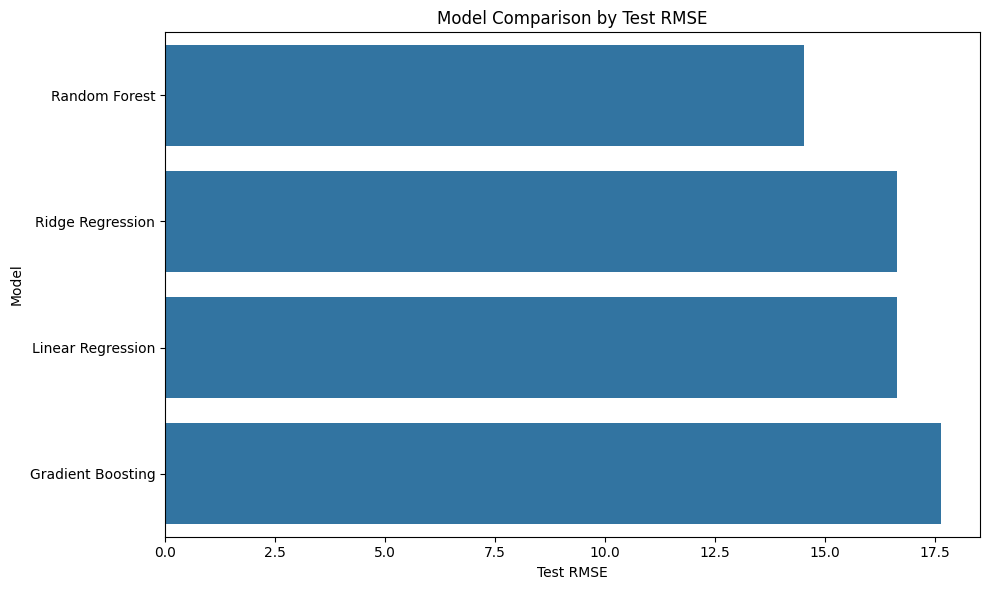

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df.sort_values("Test RMSE"),
    x="Test RMSE",
    y="Model"
)

plt.title("Model Comparison by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    MODELS_PATH / "model_comparison_rmse.png",
    dpi=300
)

plt.show()

### **3.3 Best model**

In [16]:
best_model_name = results_df.sort_values("Test RMSE").iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"Best model: {best_model_name}")

Best model: Random Forest


Saving best model

In [17]:
joblib.dump(
    best_model,
    MODELS_PATH / "best_popularity_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


### **3.4 Actual vs Predicted values & Residuals**

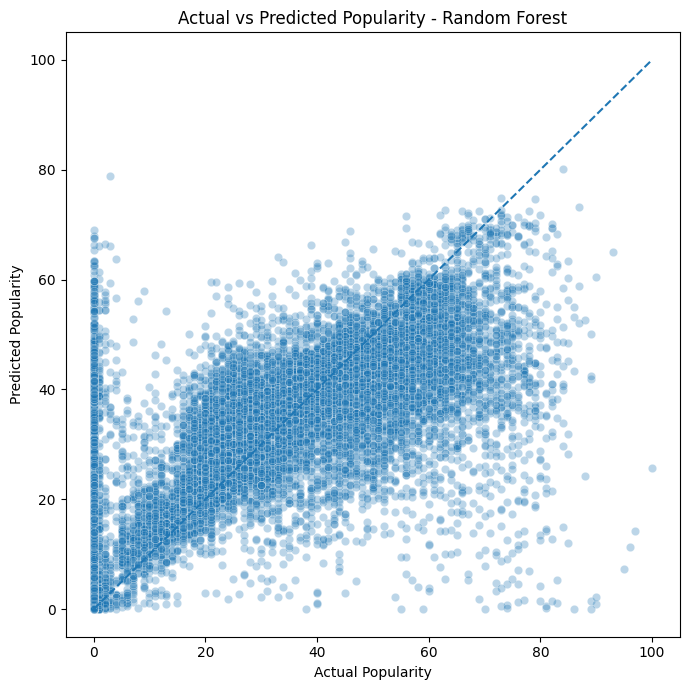

In [18]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Popularity - {best_model_name}")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")

plt.tight_layout()

plt.savefig(
    MODELS_PATH / "actual_vs_predicted.png",
    dpi=300
)

plt.show()

Residuals

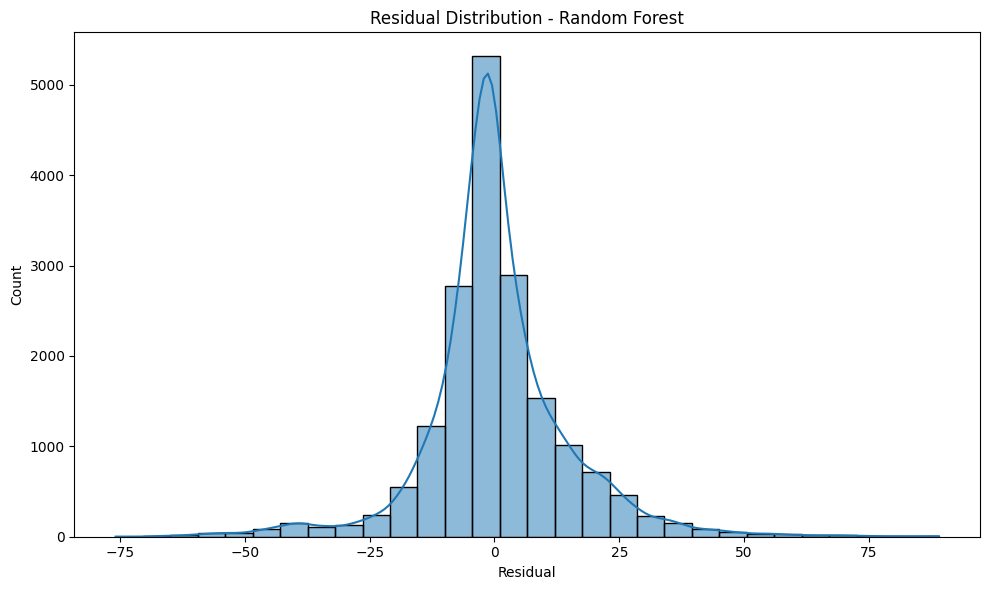

In [19]:
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    MODELS_PATH / "residual_distribution.png",
    dpi=300
)

plt.show()

### **3.5 Feature Importance**

In [20]:
best_model = models[best_model_name]

In [21]:
if hasattr(best_model, "feature_importances_"):

    feature_importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    feature_importance_df.head(20)

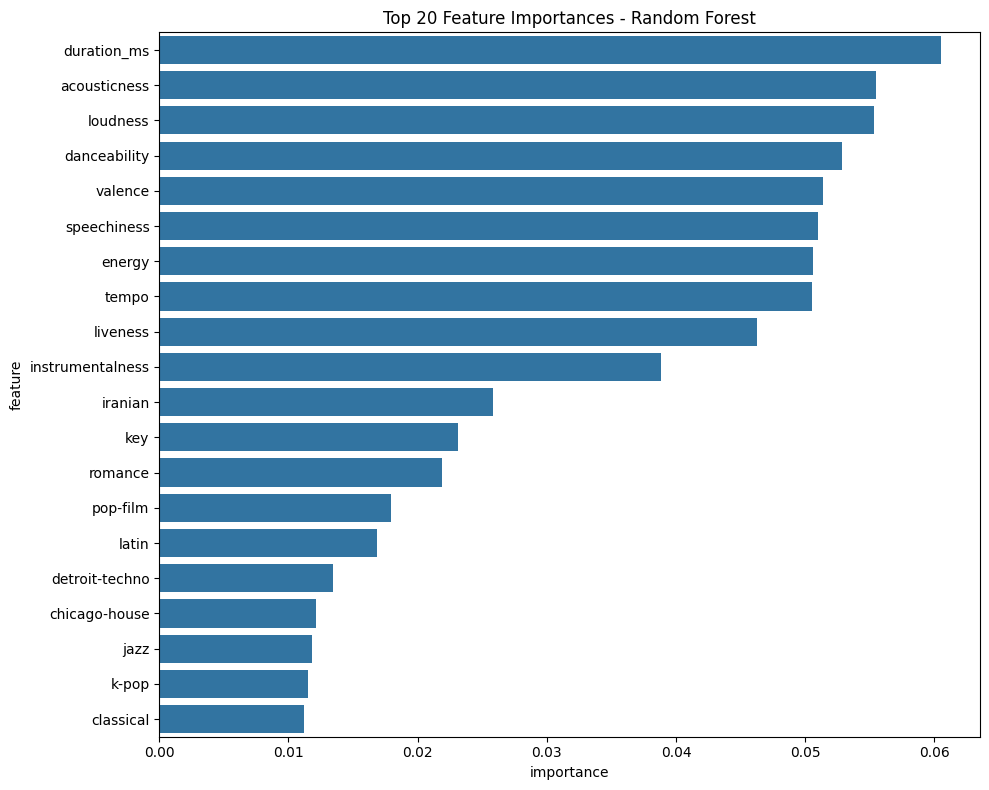

In [22]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title(f"Top 20 Feature Importances - {best_model_name}")

plt.tight_layout()

plt.savefig(
    MODELS_PATH / "feature_importance.png",
    dpi=300
)

plt.show()

### **3.6 Investigate duration outliers**

In [23]:
df["duration_minutes"] = df["duration_ms"] / 60000

In [24]:
df["duration_minutes"].describe()

count    89740.000000
mean         3.819073
std          1.882430
min          0.143100
25%          2.884000
50%          3.554925
75%          4.404883
max         87.288250
Name: duration_minutes, dtype: float64

There are some extreme values

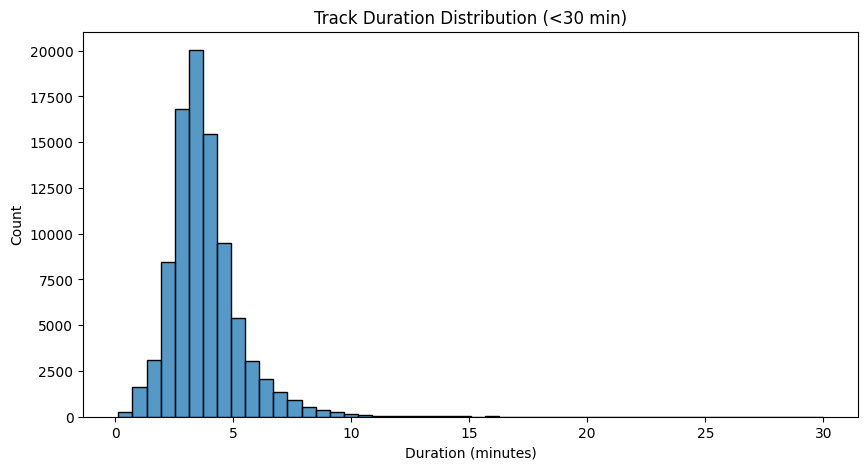

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[df["duration_minutes"] < 30]["duration_minutes"],
    bins=50
)

plt.title("Track Duration Distribution (<30 min)")
plt.xlabel("Duration (minutes)")

plt.savefig(
    MODELS_PATH / "track_duration_distribution.png",
    dpi=300
)

plt.show()

Analysis shows that most tracks exhibit realistic music durations centred around approximately 3–4 minutes, although there is a small number of long-duration outliers.

This suggests that track duration may genuinely influence popularity patterns, potentially reflecting listener preferences for radio-friendly song lengths or differences between mainstream and niche audio content

### **GridSearchCV**

In the 3 below cells, I attempted to run GridSearchCV to no avail, as the processing time took too long, even after tinkering with parementers several times

In [26]:
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# from scipy.stats import randint, uniform


In [27]:
# param_grids = {

#     "Ridge Regression": {
#         "model__alpha": [0.1, 1.0, 10.0, 100.0, 300.0]
#     },

#     "Random Forest": {
#         "n_estimators": randint(100, 350),
#         "max_depth": [None, 10, 20, 30],
#         "min_samples_split": randint(2, 11),
#         "min_samples_leaf": randint(1, 5),
#         "max_features": ["sqrt", "log2"]
#     },

#     "Gradient Boosting": {
#         "n_estimators": randint(100, 350),
#         "learning_rate": uniform(0.01, 0.1),
#         "max_depth": randint(2, 5),
#         "subsample": uniform(0.8, 0.2)
#     }
# }


In [28]:
# tuned_models = {}

# for model_name, model in models.items():

#     print(f"Tuning {model_name}...")

#     if model_name in param_grids:

#         # Ridge to GridSearchCV
#         if model_name == "Ridge Regression":
#             search = GridSearchCV(
#                 estimator=model,
#                 param_grid=param_grids[model_name],
#                 cv=5,
#                 scoring="neg_root_mean_squared_error",
#                 n_jobs=-1
#             )

#         # Random Forest + Gradient Boosting → RandomizedSearchCV
#         else:
#             search = RandomizedSearchCV(
#                 estimator=model,
#                 param_distributions=param_grids[model_name],
#                 n_iter=15, #changed from 40 to 15, as it was running forever
#                 cv=5, #CV folds from 4 to 3
#                 scoring="neg_root_mean_squared_error",
#                 n_jobs=-1,
#                 random_state=42
#             )

#         search.fit(X_train, y_train)
#         tuned_models[model_name] = search.best_estimator_

#         print(f"Best params for {model_name}: {search.best_params_}")

#     else:
#         # Models without tuning (Linear Regression)
#         model.fit(X_train, y_train)
#         tuned_models[model_name] = model


# 4. **Learning Curve Analysis**

In [29]:
# # Generate learning curve values
# train_sizes, train_scores, validation_scores = learning_curve(
#     estimator=best_model,              # random forest
#     X=X_train,
#     y=y_train,
#     train_sizes=np.linspace(0.1, 1.0, 5),
#     cv=5,
#     scoring="r2",
#     n_jobs=-1,
#     random_state=42
# )

# # Calculate mean and standard deviation
# train_scores_mean = train_scores.mean(axis=1)
# train_scores_std = train_scores.std(axis=1)

# validation_scores_mean = validation_scores.mean(axis=1)
# validation_scores_std = validation_scores.std(axis=1)



In [30]:
# # Plot learning curve
# plt.figure(figsize=(10, 6))

# plt.plot(
#     train_sizes,
#     train_scores_mean,
#     marker="o",
#     label="Training score"
# )

# plt.plot(
#     train_sizes,
#     validation_scores_mean,
#     marker="o",
#     label="Validation score"
# )

# plt.fill_between(
#     train_sizes,
#     train_scores_mean - train_scores_std,
#     train_scores_mean + train_scores_std,
#     alpha=0.15
# )

# plt.fill_between(
#     train_sizes,
#     validation_scores_mean - validation_scores_std,
#     validation_scores_mean + validation_scores_std,
#     alpha=0.15
# )

# plt.title("Learning Curve - Random Forest")
# plt.xlabel("Training Set Size")
# plt.ylabel("R² Score")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# **4. Error Analysis**

### **4.1 Create Prediction Dataframe**

In [31]:
prediction_analysis_df = pd.DataFrame({
    "actual_popularity": y_test,
    "predicted_popularity": best_predictions
})

prediction_analysis_df["absolute_error"] = (
    prediction_analysis_df["actual_popularity"]
    - prediction_analysis_df["predicted_popularity"]
).abs()

### **4.2 Create Popularity Buckets**

In [32]:
prediction_analysis_df["popularity_bucket"] = pd.cut(
    prediction_analysis_df["actual_popularity"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        "0-20",
        "21-40",
        "41-60",
        "61-80",
        "81-100"
    ],
    include_lowest=True
)

### **4.3 Aggregate Errors**

In [33]:
bucket_error_analysis = (
    prediction_analysis_df
    .groupby("popularity_bucket")["absolute_error"]
    .mean()
    .reset_index()
)

bucket_error_analysis

,popularity_bucket,absolute_error
0,0-20,10.250677
1,21-40,6.278223
2,41-60,8.511738
3,61-80,21.093728
4,81-100,45.099842


### **4.4 Plot Bucket Errors**

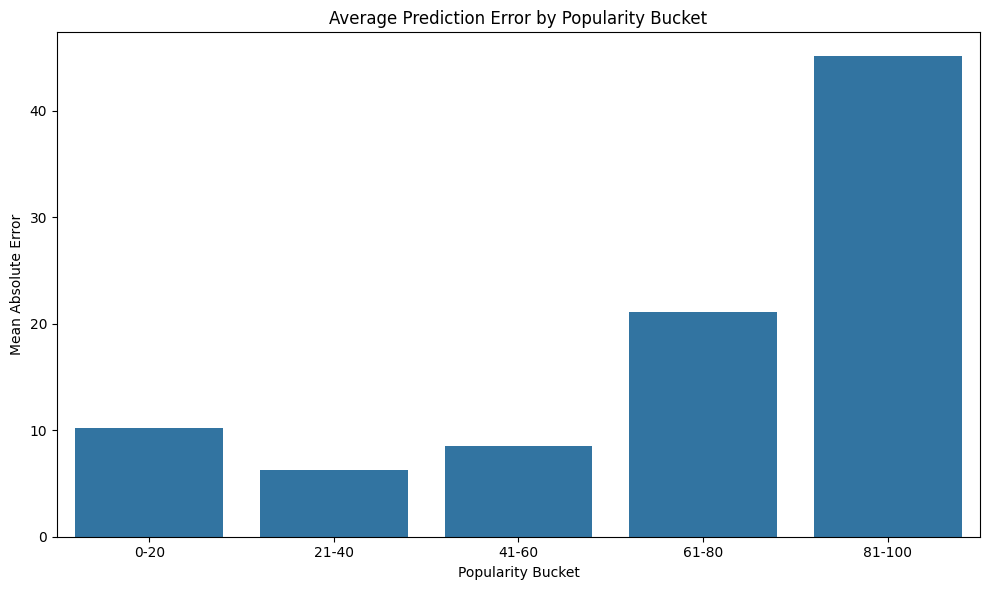

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bucket_error_analysis,
    x="popularity_bucket",
    y="absolute_error"
)

plt.title("Average Prediction Error by Popularity Bucket")
plt.xlabel("Popularity Bucket")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "popularity_bucket_error.png",
    dpi=300
)

plt.show()

Very high prediction error for the most popular tracks. 

# **5. Conclusions of this Notebook**

### **5.1 Modelling Performance**
Several regression models were trained and evaluated to predict Spotify track popularity using audio characteristics and aggregated genre features. A dummy baseline regressor was first established to provide a minimum performance benchmark, achieving a Test RMSE of approximately 20.6 and near-zero explanatory power.

Both Linear Regression and Ridge Regression substantially outperformed the baseline model, achieving Test R² scores of approximately 0.35. This indicates that the dataset contains meaningful predictive signal, although the relationships between features and popularity are not purely linear.

Among all evaluated models, the Random Forest achieved the strongest predictive performance, with:

*   Test RMSE ≈ 14.5
*   Test MAE ≈ 9.7
*   Test R² ≈ 0.50

This suggests that approximately half of the variance in Spotify popularity can be explained using the available audio and genre features. The superior performance of the Random Forest model compared to linear approaches indicates that popularity is influenced by complex and non-linear interactions between musical characteristics.

### **5.2 Model Behaviour and Error Analysis**
Residual analysis demonstrated that prediction errors were generally centred around zero and followed an approximately bell-shaped distribution, indicating that the model does not exhibit severe systematic bias.

However, the Actual vs Predicted plot revealed that the model struggles to accurately predict extreme popularity values. Highly popular tracks are frequently underpredicted, while some low-popularity tracks are overpredicted. This behaviour is consistent with regression models tending to predict toward the mean and suggests that factors external to the dataset likely influence popularity outcomes.

Potential missing factors could be artist reputation, marketing exposure, playlist placement, social media exposure, release timing, among others. These variables are not captured within the current dataset.

### **5.3 Overall Assessment**
The modelling results demonstrate that Spotify popularity can be partially predicted using intrinsic audio features and genre information. However, the moderate performance ceiling observed across models suggests that popularity is also heavily influenced by external social and commercial factors beyond the scope of the dataset.
